# Blood Glucose Prediction — 30-Minute CGM Forecasting

**Goal:** Predict a patient's blood glucose level 30 minutes into the future.

| Stage | Description |
|---|---|
| Data | 90 days, 5-min intervals, 25,920 readings |
| Features | 48 engineered features |
| Models | Linear Regression, Ridge, Random Forest, XGBoost |
| Target | Glucose (mg/dL) 30 minutes ahead |
| Best Result | MAE = 2.39 mg/dL, R² = 0.986 |

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✓')

Libraries loaded ✓


In [3]:
import os
print(os.getcwd())

/Users/ganeshvathyaram/cgm-glucose-predictor


In [4]:
df_raw = pd.read_csv('data/raw/cgm_raw.csv', parse_dates=['timestamp'])

print(f'Shape:         {df_raw.shape}')
print(f'Date range:    {df_raw.timestamp.min()} → {df_raw.timestamp.max()}')
print(f'Missing values:{df_raw.glucose_mg_dl.isna().sum()}')
print(f'Glucose range: {df_raw.glucose_mg_dl.min():.1f} – {df_raw.glucose_mg_dl.max():.1f} mg/dL')

df_raw.head()

Shape:         (25920, 4)
Date range:    2024-01-01 00:00:00 → 2024-03-30 23:55:00
Missing values:534
Glucose range: 73.3 – 167.8 mg/dL


,timestamp,glucose_mg_dl,patient_id,device
0,2024-01-01 00:00:00,91.490347,P001,Dexcom_G6_sim
1,2024-01-01 00:05:00,89.587857,P001,Dexcom_G6_sim
2,2024-01-01 00:10:00,91.952938,P001,Dexcom_G6_sim
3,2024-01-01 00:15:00,94.590965,P001,Dexcom_G6_sim
4,2024-01-01 00:20:00,89.336200,P001,Dexcom_G6_sim


In [5]:
#Load Cleaned data and show summary stats
df_clean = pd.read_csv('data/processed/cgm_clean.csv', parse_dates=['timestamp'])

print(f'Shape: {df_clean.shape}')
print(f'Remaining NaNs: {df_clean.glucose_mg_dl.isna().sum()}')

df_clean.describe().round(2)

Shape: (25920, 10)
Remaining NaNs: 0


,timestamp,glucose_mg_dl,hour,minute,day_of_week,is_weekend,time_of_day_sin,time_of_day_cos
count,25920,25920.00,25920.00,25920.00,25920.00,25920.00,25920.00,25920.00
mean,2024-02-14 23:57:30,126.30,11.50,27.50,2.97,0.28,0.00,-0.00
min,2024-01-01 00:00:00,73.31,0.00,0.00,0.00,0.00,-1.00,-1.00
25%,2024-01-23 11:58:45,99.64,5.75,13.75,1.00,0.00,-0.71,-0.71
50%,2024-02-14 23:57:30,133.19,11.50,27.50,3.00,0.00,0.00,-0.00
75%,2024-03-08 11:56:15,148.59,17.25,41.25,5.00,1.00,0.71,0.71
max,2024-03-30 23:55:00,167.79,23.00,55.00,6.00,1.00,1.00,1.00
std,NaN,25.34,6.92,17.26,1.99,0.45,0.71,0.71


In [8]:
import visualizations
print(visualizations.__file__)

None


In [9]:
import sys
import os

os.chdir('/Users/ganeshvathyaram/cgm-glucose-predictor')

# Remove any conflicting visualizations module
for key in list(sys.modules.keys()):
    if 'visualizations' in key:
        del sys.modules[key]

# Force src to be first in path
sys.path.insert(0, '/Users/ganeshvathyaram/cgm-glucose-predictor/src')

print(sys.path[0])
print('Ready')

/Users/ganeshvathyaram/cgm-glucose-predictor/src
Ready


In [10]:
import visualizations
print(visualizations.__file__)

/Users/ganeshvathyaram/cgm-glucose-predictor/src/visualizations.py


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df_raw   = pd.read_csv('data/raw/cgm_raw.csv', parse_dates=['timestamp'])
df_clean = pd.read_csv('data/processed/cgm_clean.csv', parse_dates=['timestamp'])
df_feat  = pd.read_csv('data/processed/cgm_features.csv', parse_dates=['timestamp'])

print(f'Raw:     {df_raw.shape}')
print(f'Clean:   {df_clean.shape}')
print(f'Features:{df_feat.shape}')

Raw:     (25920, 4)
Clean:   (25920, 10)
Features:(25890, 53)


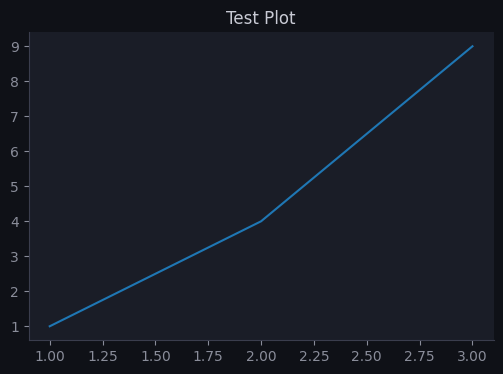

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot([1,2,3], [1,4,9])
plt.title("Test Plot")
plt.show()

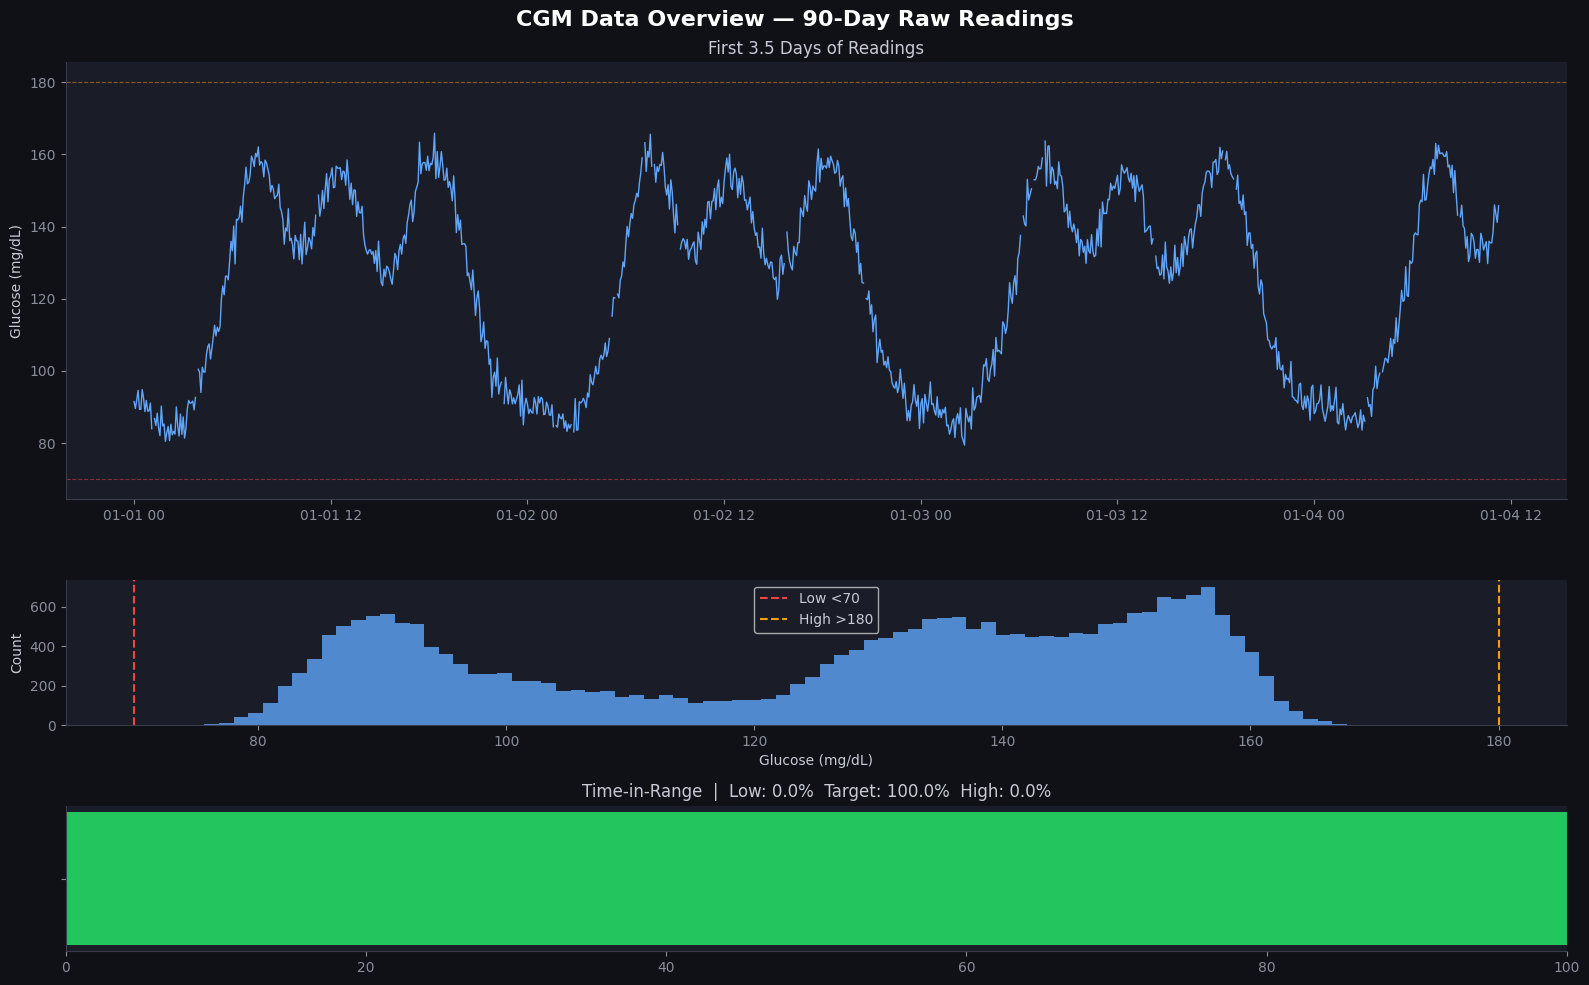

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

df_raw = pd.read_csv('data/raw/cgm_raw.csv', parse_dates=['timestamp'])

fig, axes = plt.subplots(3, 1, figsize=(16, 10),
                         gridspec_kw={"height_ratios": [3, 1, 1]})
fig.suptitle("CGM Data Overview — 90-Day Raw Readings",
             fontsize=16, fontweight="bold", color="white")

# Panel 1: time series
subset = df_raw.iloc[:1000]
axes[0].plot(subset["timestamp"], subset["glucose_mg_dl"], color="#60a5fa", lw=1.0)
axes[0].axhline(70,  color="#ef4444", lw=0.8, ls="--", alpha=0.5)
axes[0].axhline(180, color="#f59e0b", lw=0.8, ls="--", alpha=0.5)
axes[0].set_ylabel("Glucose (mg/dL)")
axes[0].set_title("First 3.5 Days of Readings")

# Panel 2: distribution
vals = df_raw["glucose_mg_dl"].dropna()
axes[1].hist(vals, bins=80, color="#60a5fa", alpha=0.8, edgecolor="none")
axes[1].axvline(70,  color="#ef4444", lw=1.5, ls="--", label="Low <70")
axes[1].axvline(180, color="#f59e0b", lw=1.5, ls="--", label="High >180")
axes[1].set_xlabel("Glucose (mg/dL)")
axes[1].set_ylabel("Count")
axes[1].legend()

# Panel 3: time-in-range
low    = (vals < 70).mean() * 100
target = ((vals >= 70) & (vals <= 180)).mean() * 100
high   = (vals > 180).mean() * 100
axes[2].barh([""], [low, target, high],
             color=["#ef4444", "#22c55e", "#f59e0b"], height=0.5)
axes[2].set_xlim(0, 100)
axes[2].set_title(f"Time-in-Range  |  Low: {low:.1f}%  Target: {target:.1f}%  High: {high:.1f}%")

plt.tight_layout()
plt.show()

           model   MAE  RMSE     R2  MAPE
LinearRegression 3.487 4.373 0.9703 2.857
           Ridge 3.487 4.373 0.9703 2.858
    RandomForest 2.393 3.001 0.9860 1.980
         XGBoost 2.426 3.046 0.9856 2.011


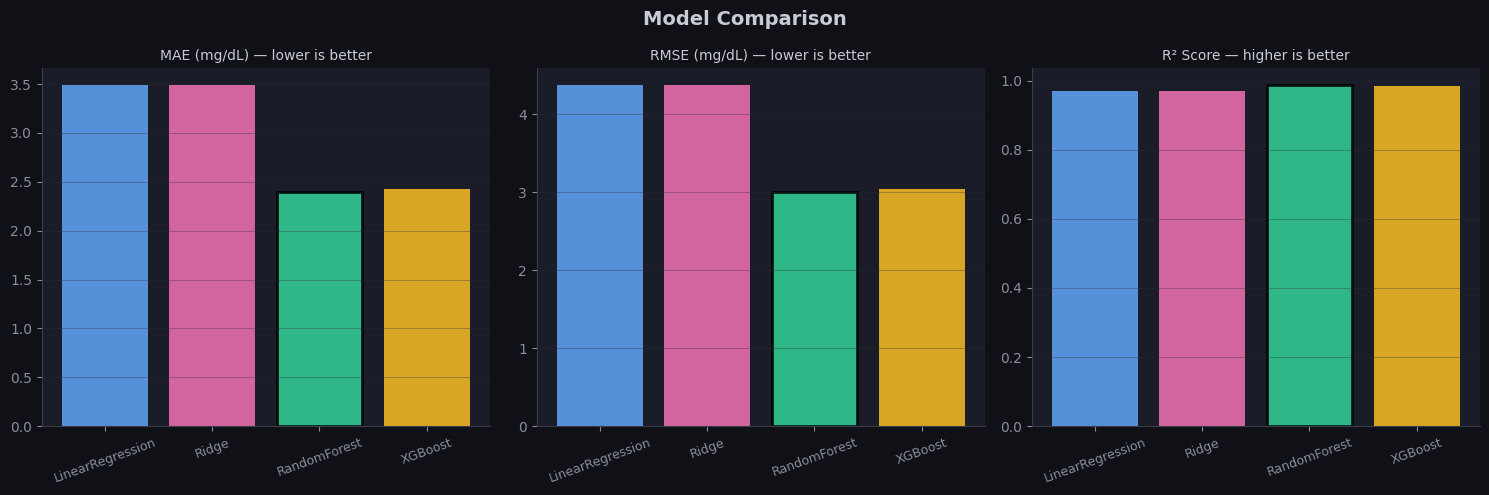

In [18]:
#Model Comparison Chart
import json

with open('reports/model_metrics.json') as f:
    metrics = json.load(f)

df_metrics = pd.DataFrame(metrics)
print(df_metrics.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison", fontsize=14, fontweight="bold")

palette = ["#60a5fa", "#f472b6", "#34d399", "#fbbf24"]

for ax, col, title in zip(
    axes,
    ["MAE", "RMSE", "R2"],
    ["MAE (mg/dL) — lower is better",
     "RMSE (mg/dL) — lower is better",
     "R² Score — higher is better"]
):
    bars = ax.bar(df_metrics["model"], df_metrics[col],
                  color=palette, edgecolor="none", alpha=0.85)
    best_idx = df_metrics[col].idxmin() if col != "R2" else df_metrics[col].idxmax()
    bars[best_idx].set_edgecolor("black")
    bars[best_idx].set_linewidth(2)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=20, labelsize=9)
    ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

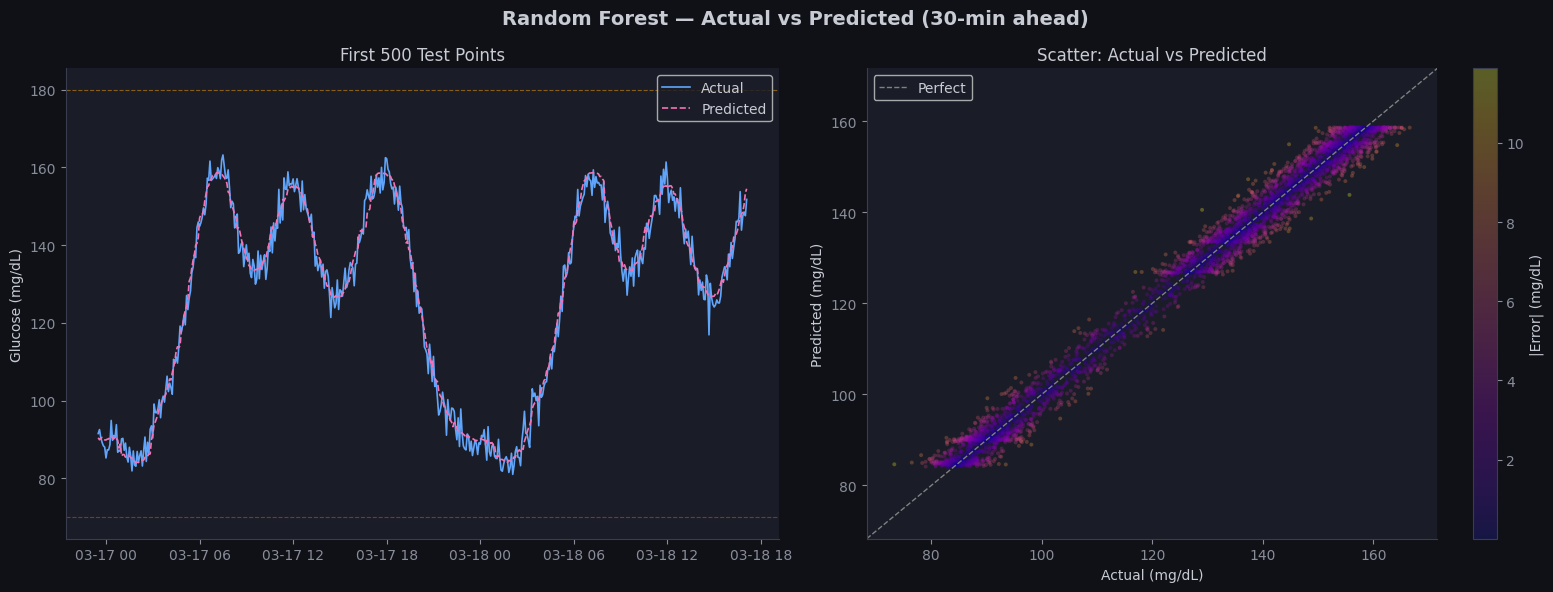

In [19]:
#Actual vs Predicted Time Series
y_test  = np.load('reports/y_test.npy')
y_pred  = np.load('reports/y_pred_best.npy')
ts      = pd.read_csv('reports/test_timestamps.csv').iloc[:, 0].values
ts      = pd.to_datetime(ts)

n = 500
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Random Forest — Actual vs Predicted (30-min ahead)",
             fontsize=14, fontweight="bold")

# Left: time series
axes[0].plot(ts[:n], y_test[:n], color="#60a5fa", lw=1.2, label="Actual")
axes[0].plot(ts[:n], y_pred[:n], color="#f472b6", lw=1.2, ls="--", label="Predicted")
axes[0].axhline(70,  color="#ef4444", lw=0.8, ls="--", alpha=0.5)
axes[0].axhline(180, color="#f59e0b", lw=0.8, ls="--", alpha=0.5)
axes[0].set_ylabel("Glucose (mg/dL)")
axes[0].set_title("First 500 Test Points")
axes[0].legend()

# Right: scatter
errors = np.abs(y_pred - y_test)
sc = axes[1].scatter(y_test, y_pred, c=errors, cmap="plasma",
                     alpha=0.3, s=8, edgecolors="none")
lim = [y_test.min() - 5, y_test.max() + 5]
axes[1].plot(lim, lim, color="gray", lw=1, ls="--", label="Perfect")
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("Actual (mg/dL)")
axes[1].set_ylabel("Predicted (mg/dL)")
axes[1].set_title("Scatter: Actual vs Predicted")
plt.colorbar(sc, ax=axes[1], label="|Error| (mg/dL)")
axes[1].legend()

plt.tight_layout()
plt.show()

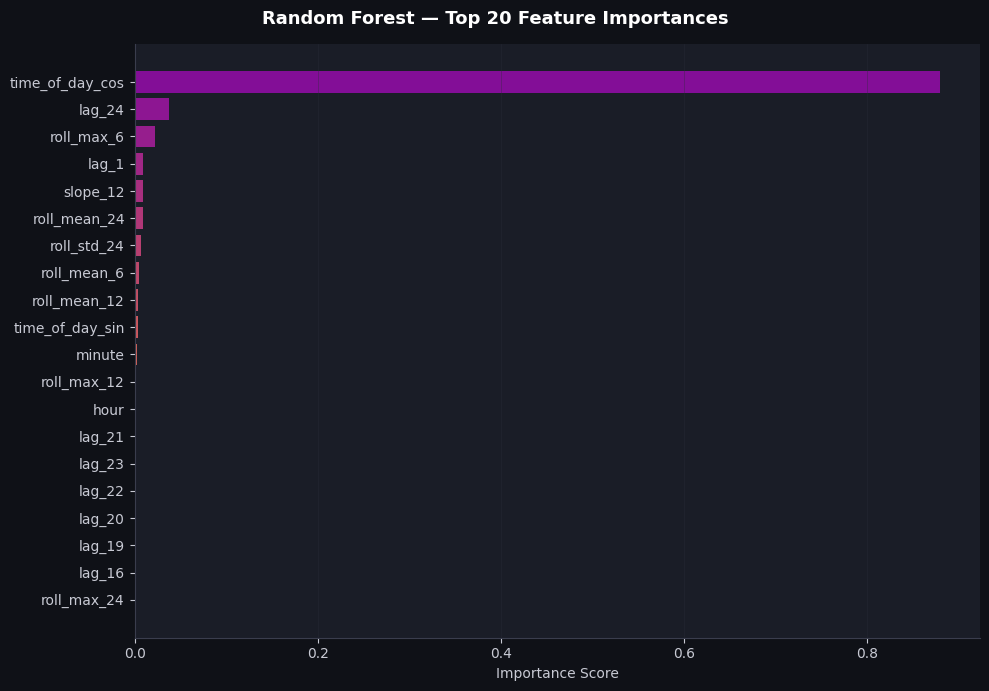

In [20]:
#Feature Importance Chart
imp_df = pd.read_csv('reports/feature_importance.csv')
top20  = imp_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor("#1a1d27")
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Random Forest — Top 20 Feature Importances",
             fontsize=13, fontweight="bold", color="white")

colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(top20)))[::-1]
ax.barh(top20["feature"][::-1], top20["importance"][::-1],
        color=colors, edgecolor="none", alpha=0.9)
ax.set_xlabel("Importance Score", color="#c8cad4")
ax.tick_params(colors="#c8cad4")
ax.grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.show()

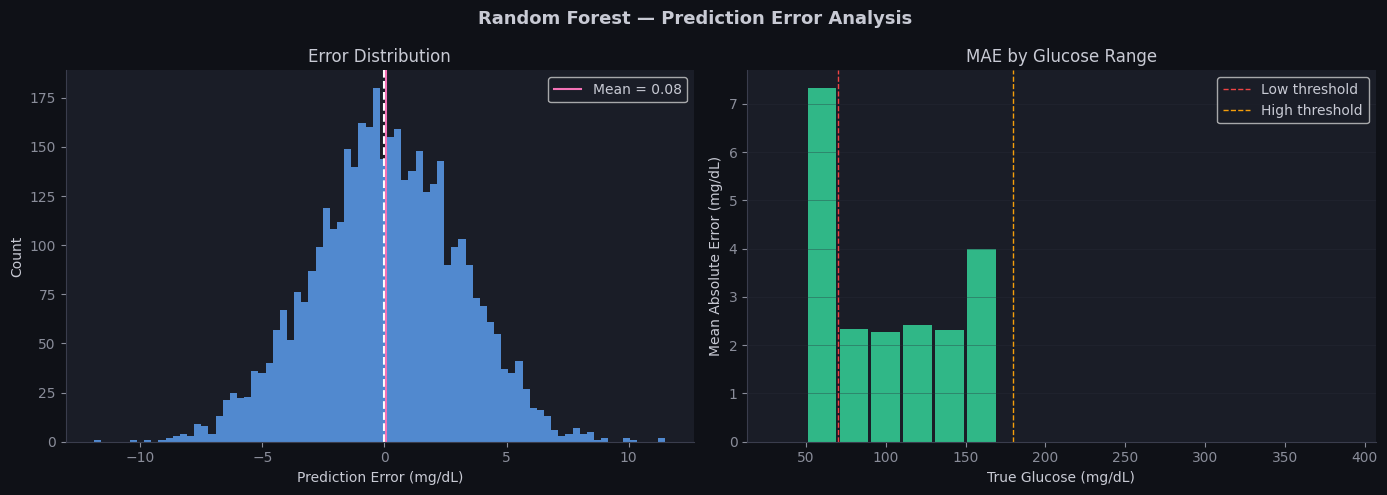

In [21]:
#Error distribution
errors = y_pred - y_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Random Forest — Prediction Error Analysis",
             fontsize=13, fontweight="bold")

# Left: error histogram
axes[0].hist(errors, bins=80, color="#60a5fa", alpha=0.8, edgecolor="none")
axes[0].axvline(0, color="white", lw=1.5, ls="--")
axes[0].axvline(errors.mean(), color="#f472b6", lw=1.5,
                label=f"Mean = {errors.mean():.2f}")
axes[0].set_xlabel("Prediction Error (mg/dL)")
axes[0].set_ylabel("Count")
axes[0].set_title("Error Distribution")
axes[0].legend()

# Right: MAE by glucose range
bins = np.arange(40, 401, 20)
bin_idx = np.digitize(y_test, bins)
bin_mae = [np.mean(np.abs(errors[bin_idx == i]))
           if (bin_idx == i).sum() > 0 else 0
           for i in range(1, len(bins))]
axes[1].bar(bins[:-1], bin_mae, width=18, color="#34d399",
            edgecolor="none", alpha=0.85)
axes[1].axvline(70,  color="#ef4444", lw=1, ls="--", label="Low threshold")
axes[1].axvline(180, color="#f59e0b", lw=1, ls="--", label="High threshold")
axes[1].set_xlabel("True Glucose (mg/dL)")
axes[1].set_ylabel("Mean Absolute Error (mg/dL)")
axes[1].set_title("MAE by Glucose Range")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

In [22]:
import joblib

model  = joblib.load('models/RandomForest.pkl')
scaler = joblib.load('models/scaler.pkl')

from feature_engineering import get_feature_columns
feature_cols = get_feature_columns(df_feat)

# Take the last row of test data as our "current moment"
sample_row    = df_feat.iloc[-1]
sample_feats  = sample_row[feature_cols].values.reshape(1, -1)
sample_scaled = scaler.transform(sample_feats)

predicted = model.predict(sample_scaled)[0]
current   = sample_row['glucose_mg_dl']
actual    = sample_row['target_glucose']

print(f"Current glucose:          {current:.1f} mg/dL")
print(f"Predicted (30 min ahead): {predicted:.1f} mg/dL")
print(f"Actual (30 min ahead):    {actual:.1f} mg/dL")
print(f"Prediction error:         {abs(predicted - actual):.1f} mg/dL")
print()

if predicted < 70:
    print("⚠️  ALERT: Hypoglycemia predicted — consider fast-acting carbohydrates")
elif predicted > 180:
    print("⚠️  ALERT: Hyperglycemia predicted — consider a correction dose")
else:
    print("✅  Glucose predicted in target range (70–180 mg/dL)")

Current glucose:          92.5 mg/dL
Predicted (30 min ahead): 90.0 mg/dL
Actual (30 min ahead):    90.4 mg/dL
Prediction error:         0.4 mg/dL

✅  Glucose predicted in target range (70–180 mg/dL)


## Results Summary

| Model | MAE (mg/dL) | RMSE (mg/dL) | R² |
|---|---|---|---|
| **Random Forest** ✅ | **2.39** | **3.00** | **0.986** |
| XGBoost | 2.43 | 3.05 | 0.986 |
| Ridge | 3.49 | 4.37 | 0.970 |
| Linear Regression | 3.49 | 4.37 | 0.970 |

## Key Findings
- All models achieved **R² > 0.97** — strong predictive power
- Random Forest achieved the best MAE of **2.39 mg/dL**
- Top features: `time_of_day_cos`, `lag_1`, `slope_12`, `roll_mean_24`
- Errors are centered near zero — no systematic bias

## Next Steps
1. Add real patient data (OhioT1DM or Tidepool dataset)
2. Add insulin dose and carb intake as features
3. Try LSTM or Transformer for sequence modeling
4. Deploy as a Streamlit web dashboard